# **Artificial Neural Networks: SONAR — Detecting Mines vs. Rocks (sonardataset.csv)**

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

**Task 1: Data Exploration and Preprocessing**

--- Dataset Shape ---
(209, 61)

--- Missing Values Count ---
Total Missing Values: 0

--- Original Target Class Distribution ---
Label
M    111
R     97
Y      1
Name: count, dtype: int64

--- Filtered Target Class Distribution ---
Label
M    111
R     97
Name: count, dtype: int64


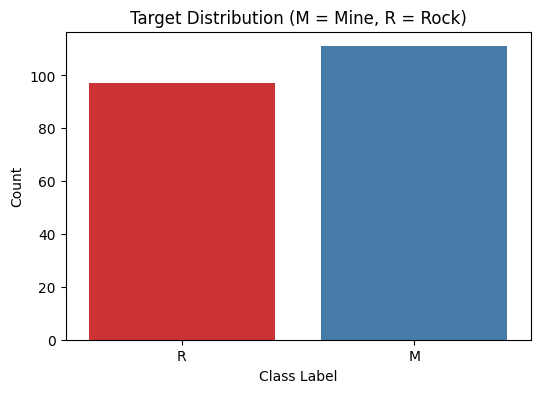

In [16]:
# Load dataset
df_sonar = pd.read_csv("/content/sonardataset.csv", header=None)

print("--- Dataset Shape ---")
print(df_sonar.shape)

# Assign feature names V1 to V60 and target 'Label'
feature_cols = [f"V{i}" for i in range(1, 61)]
df_sonar.columns = feature_cols + ["Label"]

print("\n--- Missing Values Count ---")
print(f"Total Missing Values: {df_sonar.isnull().sum().sum()}")

print("\n--- Original Target Class Distribution ---")
print(df_sonar["Label"].value_counts())

# Filter out 'Y' class as it has only 1 member, causing issues with stratification
df_sonar = df_sonar[df_sonar['Label'] != 'Y'].copy()

print("\n--- Filtered Target Class Distribution ---")
print(df_sonar["Label"].value_counts())

# Data Visualizations
plt.figure(figsize=(6, 4))
sns.countplot(x="Label", data=df_sonar, hue="Label", palette="Set1", legend=False)
plt.title("Target Distribution (M = Mine, R = Rock)")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

# Separate Features (X) and Target (y)
X = df_sonar[feature_cols]
y_raw = df_sonar["Label"]

# Label Encoding for Target: M -> 1, R -> 0
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standard Normalization (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Task 2: Baseline Neural Network Model Implementation**

In [18]:
# Construct basic ANN (1 Hidden Layer with 12 units)
base_ann = MLPClassifier(
    hidden_layer_sizes=(12,),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42,
)
base_ann.fit(X_train_scaled, y_train)

y_pred_base = base_ann.predict(X_test_scaled)

print("--- Baseline ANN Performance ---")
print("Accuracy :", accuracy_score(y_test, y_pred_base))
print("Precision:", precision_score(y_test, y_pred_base))
print("Recall   :", recall_score(y_test, y_pred_base))
print("F1-Score :", f1_score(y_test, y_pred_base))

--- Baseline ANN Performance ---
Accuracy : 0.9047619047619048
Precision: 0.9444444444444444
Recall   : 0.85
F1-Score : 0.8947368421052632


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


**Task 3: Hyperparameter Tuning via Grid Search**

In [19]:
param_grid = {
    "hidden_layer_sizes": [(12,), (24,), (60,), (24, 12), (60, 24)],
    "activation": ["relu", "tanh"],
    "learning_rate_init": [0.001, 0.01, 0.1],
    "alpha": [0.0001, 0.001, 0.01],  # L2 Regularization parameter
}

grid_search = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
grid_search.fit(X_train_scaled, y_train)

print("\n--- Best Hyperparameters ---")
print(grid_search.best_params_)

tuned_ann = grid_search.best_estimator_


--- Best Hyperparameters ---
{'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (24,), 'learning_rate_init': 0.1}


**Task 4: Evaluation and Comparison**


--- Tuned ANN Performance ---
Accuracy : 0.9047619047619048
Precision: 0.9444444444444444
Recall   : 0.85
F1-Score : 0.8947368421052632


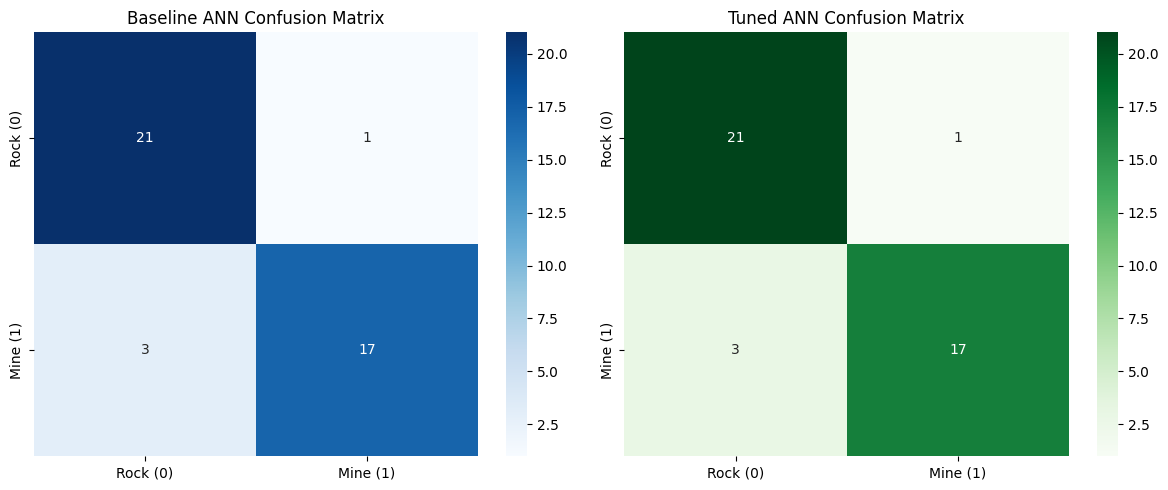


--- Final Tuned ANN Classification Report ---
              precision    recall  f1-score   support

    Rock (R)       0.88      0.95      0.91        22
    Mine (M)       0.94      0.85      0.89        20

    accuracy                           0.90        42
   macro avg       0.91      0.90      0.90        42
weighted avg       0.91      0.90      0.90        42



In [20]:
y_pred_tuned = tuned_ann.predict(X_test_scaled)

print("\n--- Tuned ANN Performance ---")
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1-Score :", f1_score(y_test, y_pred_tuned))

# Confusion Matrix Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_base = confusion_matrix(y_test, y_pred_base)
sns.heatmap(
    cm_base,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Rock (0)", "Mine (1)"],
    yticklabels=["Rock (0)", "Mine (1)"],
)
axes[0].set_title("Baseline ANN Confusion Matrix")

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1],
    xticklabels=["Rock (0)", "Mine (1)"],
    yticklabels=["Rock (0)", "Mine (1)"],
)
axes[1].set_title("Tuned ANN Confusion Matrix")

plt.tight_layout()
plt.show()

# Detailed Classification Report
print("\n--- Final Tuned ANN Classification Report ---")
print(
    classification_report(
        y_test, y_pred_tuned, target_names=["Rock (R)", "Mine (M)"]
    )
)